# Grocery Habit

My grocery habit in 2024.

## Import packages

In [1]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import re

## Load dataset

In [2]:
# Creating the table in dataframe from a csv file
df_dirty = pd.read_csv(r"C:\Users\Clair\Documents\Code Development\Python Local\personal_finance\Grocery Habit.csv")

In [3]:
df_dirty

,Date,Month,Store,Money Spent
0,6/10/2022,6,Publix,120.58
1,6/26/2022,6,Publix,69.33
2,7/10/2022,7,Publix,84.99
3,7/16/2022,7,Publix,6.43
4,7/23/2022,7,Publix,28.91
...,...,...,...,...
204,3/9/2025,3,Walmart,84.69
205,3/15/2025,3,Food City,51.87
206,3/15/2025,3,Local Asian Market,22.81
207,3/16/2025,3,Walmart,49.93


In [4]:
df_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         209 non-null    object 
 1   Month        209 non-null    int64  
 2   Store        209 non-null    object 
 3   Money Spent  209 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.7+ KB


In [5]:
# convert the date column to date (it's already formatted as short date in csv)
import pandas as pd

# Convert "Date" column to datetime format
df_dirty["Date"] = pd.to_datetime(df_dirty["Date"])

# Check the data types after conversion
print(df_dirty.dtypes)

# Preview the DataFrame to verify the conversion
print(df_dirty.head())


Date           datetime64[ns]
Month                   int64
Store                  object
Money Spent           float64
dtype: object
        Date  Month   Store  Money Spent
0 2022-06-10      6  Publix       120.58
1 2022-06-26      6  Publix        69.33
2 2022-07-10      7  Publix        84.99
3 2022-07-16      7  Publix         6.43
4 2022-07-23      7  Publix        28.91


In [6]:
# df = df_dirty.copy()
# # extract year from Date column using regular expressions  
# df["Year"] = df["Date"].apply(lambda x: re.search(r"\d{4}", x).group())  
# df_2024 = df[df["Year"] == "2023"]  

df = df_dirty.copy()

# Convert "Date" column to datetime format
#df["Date"] = pd.to_datetime(df["Date"])

# Extract year from datetime column
df["Year"] = df["Date"].dt.year

# Filter data for the year 2023
df_2024 = df[df["Year"] == 2024]

print(df_2024.head())


          Date  Month               Store  Money Spent  Year
126 2024-01-01      1           Food City        35.25  2024
127 2024-01-06      1                Aldi        34.60  2024
128 2024-01-07      1           Food City        10.82  2024
129 2024-01-08      1  Local Asian Market        35.76  2024
130 2024-01-13      1                Aldi        21.26  2024


<Axes: >

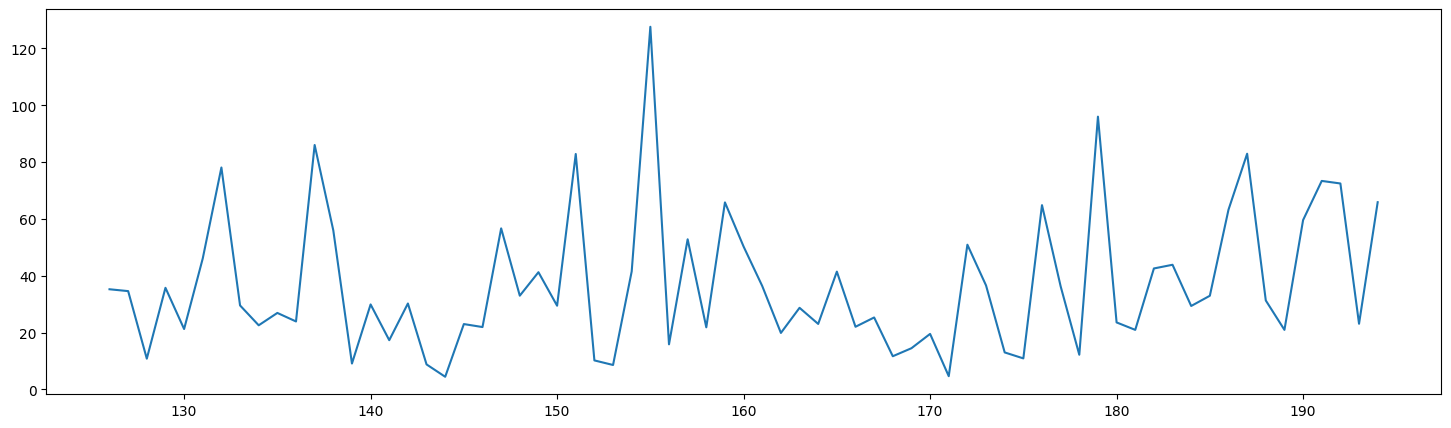

In [7]:
# Big picture - identifying pattern with money spending
df_2024['Money Spent'].plot(figsize = (18,5))

In [8]:
# Checking for null values
df_2024.isnull().values.any()

False

## Clean/modify data

In [9]:
# Converting the date object mm/dd/yyyy to another date object mm-dd-yyyy
df_2024["Date"] = pd.to_datetime(df_2024["Date"]).dt.date
print(df_2024.dtypes,'\n')

# Previewing the table - just checking the Date columns is properly converted
print(df_2024.head(2))

Date            object
Month            int64
Store           object
Money Spent    float64
Year             int32
dtype: object 

           Date  Month      Store  Money Spent  Year
126  2024-01-01      1  Food City        35.25  2024
127  2024-01-06      1       Aldi        34.60  2024


C:\Users\Clair\AppData\Local\Temp\ipykernel_19224\2567483758.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024["Date"] = pd.to_datetime(df_2024["Date"]).dt.date


### High level

In [10]:
# Extremes
Cheap = df_2024['Money Spent'].min()
Expensive = df_2024['Money Spent'].max()
Paid = df_2024['Money Spent'].sum().round(2)

print(f'Most cheap trip:\n $',Cheap,'\n')
print(f'Most expensive trip:\n $',Expensive,'\n')
print(f'Amount spent toward feeding myself thus far:\n $',Paid,'\n')

Most cheap trip:
 $ 4.45 

Most expensive trip:
 $ 127.63 

Amount spent toward feeding myself thus far:
 $ 2543.8 



In [11]:
# Basic stats by store
print('The amount of money I spend at each of the main stores:')
Store_group = df_2024.groupby(['Store']).agg({'Money Spent': ['min', 'max', 'mean', 'median']}).round(2)
Store_group.columns = ['min', 'max', 'mean', 'median']
Store_group.reset_index()
Store_group

The amount of money I spend at each of the main stores:


,min,max,mean,median
Store,,,,
Aldi,4.45,34.60,21.44,23.32
Food City,4.66,78.10,29.31,24.16
Local Asian Market,20.96,55.97,31.24,28.72
Publix,41.53,82.86,63.43,65.89
Walmart,10.21,127.63,62.12,64.86


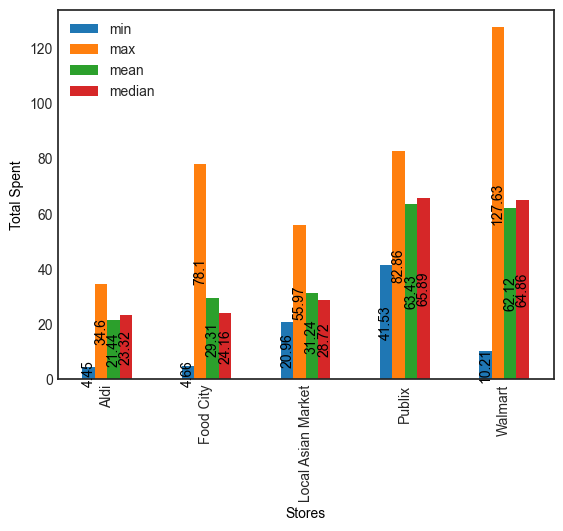

In [12]:
# Stats grouped by store viz
matplotlib.style.use('seaborn-v0_8-white') 
ax = Store_group.plot.bar()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', rotation = 'vertical', color = 'black', fontsize = 10)

plt.xlabel('Stores', size = 10, color = 'black')
plt.ylabel('Total Spent', size = 10, color = 'black')


plt.show()

In [13]:
# Count of trips by store in the last x months
Trip_count = df_2024['Store'].value_counts()
print(Trip_count)

Store
Food City             28
Walmart               15
Aldi                  12
Local Asian Market    11
Publix                 3
Name: count, dtype: int64


<Axes: ylabel='count'>

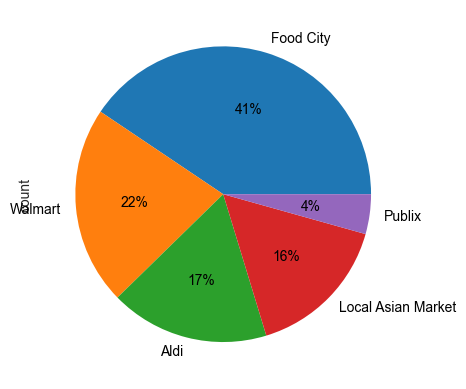

In [14]:
Trip_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

### Total

#### Monthly

In [15]:
# Spending per month
Monthly_split_total = df_2024.groupby('Month')['Money Spent'].sum()
Monthly_split_total

Month
1     291.45
2     271.75
3     219.36
6     172.66
7     334.29
8     223.04
9     236.81
10    239.18
11    320.40
12    234.86
Name: Money Spent, dtype: float64

In [16]:
# Spending per month avg
Monthly_split_avg = df_2024.groupby('Month')['Money Spent'].median()
Monthly_split_avg

Month
1     34.925
2     25.420
3     26.620
6     29.460
7     51.560
8     23.050
9     27.915
10    33.075
11    32.960
12    69.185
Name: Money Spent, dtype: float64

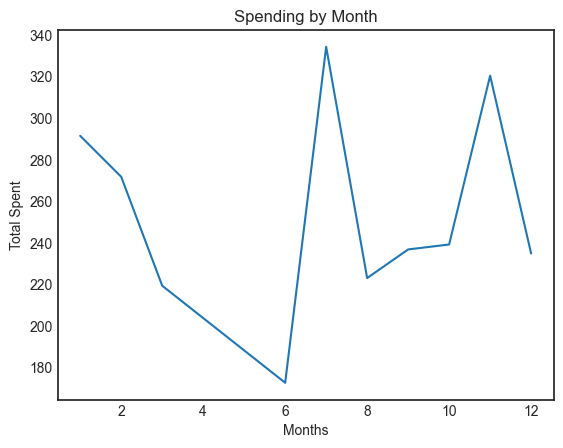

In [17]:
Monthly_split_total.plot(kind = 'line')

plt.title('Spending by Month')
plt.xlabel('Months')
plt.ylabel('Total Spent')

plt.show()

#### Store

In [18]:
# Total Spending by store
Store_split = df_2024.groupby('Store')['Money Spent'].sum()
Store_split

Store
Aldi                  257.28
Food City             820.74
Local Asian Market    343.66
Publix                190.28
Walmart               931.84
Name: Money Spent, dtype: float64

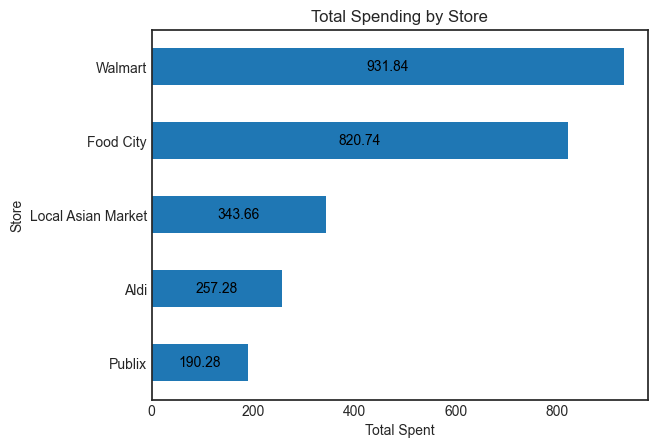

In [19]:
# sort the values in desc order so the barh will be most to least
Store_split = Store_split.sort_values(ascending=True) 
ax = Store_split.plot.barh()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', color = 'black', fontsize = 10)
    

plt.title('Total Spending by Store')
plt.xlabel('Total Spent')
plt.ylabel('Store')

plt.show()